In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

Matplotlib is building the font cache; this may take a moment.


In [13]:
df = pd.read_csv("data/raw/complaints.csv")

print("Full dataset shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/complaints.csv'

In [14]:
import os

print(os.getcwd())

/Users/mac/rag-complaint-chatbot/notebooks


In [16]:
import pandas as pd

df = pd.read_csv("../data/raw/complaints.csv")

print("Full dataset shape:", df.shape)
df.head()

/var/folders/ft/d1fl3z1d1r1_8xbh4jzfqnrh0000gn/T/ipykernel_15704/830657794.py:3: DtypeWarning: Columns (0: Consumer complaint narrative) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


Full dataset shape: (15979491, 16)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-07-26T14:04:39.000Z,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",SC,29555,NaN,Web,2023-07-26T14:14:06.000Z,Closed with non-monetary relief,Yes,7305072
1,2023-07-26T14:14:10.000Z,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,SC,29555,NaN,Web,2023-07-26T14:14:14.000Z,Closed with explanation,Yes,7305063
2,2023-10-02T13:49:26.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,I checked my credit report and found this acco...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,SC,295XX,NaN,Web,2023-10-02T13:53:19.000Z,Closed with explanation,Yes,7622437
3,2023-10-02T13:39:18.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,I checked my credit report and found this acco...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",SC,295XX,NaN,Web,2023-10-02T13:48:51.000Z,Closed with non-monetary relief,Yes,7622434
4,2023-10-02T13:53:53.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,I checked my credit report and found this acco...,NaN,"EQUIFAX, INC.",SC,295XX,NaN,Web,2023-10-02T13:56:27.000Z,Closed with non-monetary relief,Yes,7620088


In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Because notebook is inside notebooks/
ROOT_DIR = Path("..")

RAW_PATH = ROOT_DIR / "data" / "raw" / "complaints.csv"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("CSV exists:", RAW_PATH.exists())
print("CSV path:", RAW_PATH.resolve())

CSV exists: True
CSV path: /Users/mac/rag-complaint-chatbot/data/raw/complaints.csv


In [18]:
sample = pd.read_csv(RAW_PATH, nrows=5, low_memory=False)

print("Columns:")
print(sample.columns.tolist())

sample.head()

Columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-07-26T14:04:39.000Z,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",SC,29555,NaN,Web,2023-07-26T14:14:06.000Z,Closed with non-monetary relief,Yes,7305072
1,2023-07-26T14:14:10.000Z,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,SC,29555,NaN,Web,2023-07-26T14:14:14.000Z,Closed with explanation,Yes,7305063
2,2023-10-02T13:49:26.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,I checked my credit report and found this acco...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,SC,295XX,NaN,Web,2023-10-02T13:53:19.000Z,Closed with explanation,Yes,7622437
3,2023-10-02T13:39:18.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,I checked my credit report and found this acco...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",SC,295XX,NaN,Web,2023-10-02T13:48:51.000Z,Closed with non-monetary relief,Yes,7622434
4,2023-10-02T13:53:53.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,I checked my credit report and found this acco...,NaN,"EQUIFAX, INC.",SC,295XX,NaN,Web,2023-10-02T13:56:27.000Z,Closed with non-monetary relief,Yes,7620088


In [23]:
top_products = pd.DataFrame(
    product_counter.most_common(20),
    columns=["Product", "Complaint Count"]
)

top_products

,Product,Complaint Count
0,Credit reporting or other personal consumer re...,10569988
1,"Credit reporting, credit repair services, or o...",2163774
2,Debt collection,1123415
3,Mortgage,451590
4,Checking or savings account,373196
5,Credit card,320127
6,Credit card or prepaid card,206356
7,"Money transfer, virtual currency, or money ser...",181577
8,Credit reporting,140426
9,Student loan,128703


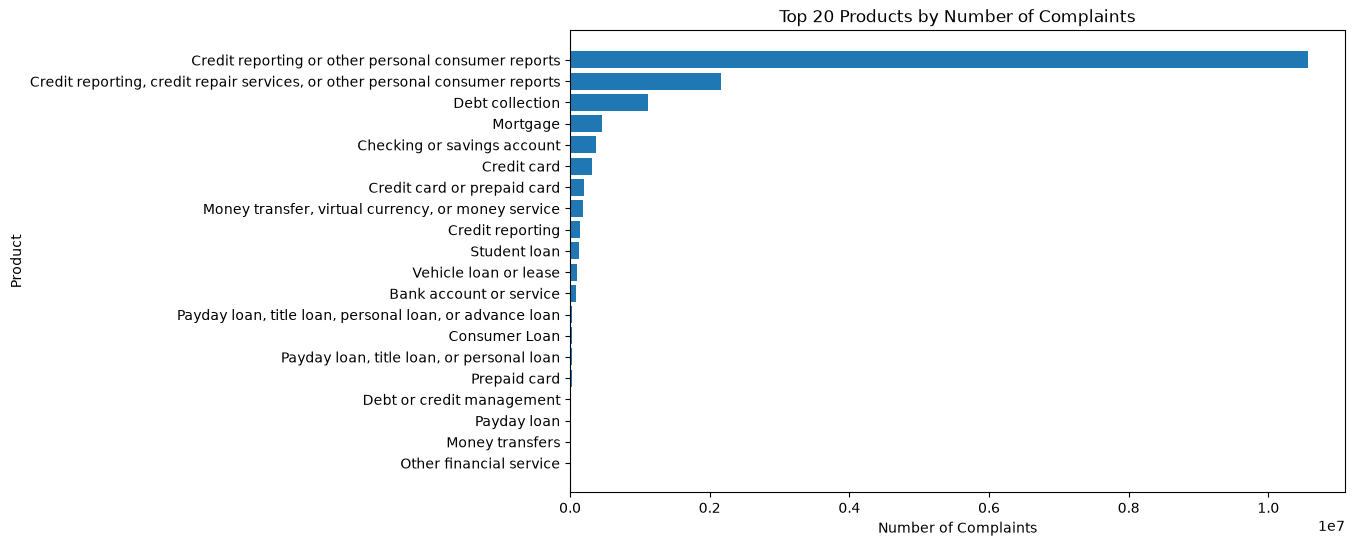

In [24]:
plt.figure(figsize=(10, 6))
plt.barh(top_products["Product"], top_products["Complaint Count"])
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.title("Top 20 Products by Number of Complaints")
plt.gca().invert_yaxis()
plt.show()

In [22]:
chunk_size = 100_000

total_rows = 0
with_narrative = 0
without_narrative = 0

product_counter = Counter()
word_count_values = []

for chunk in pd.read_csv(RAW_PATH, chunksize=chunk_size, low_memory=False):
    total_rows += len(chunk)

    product_counter.update(chunk["Product"].dropna())

    narrative = chunk["Consumer complaint narrative"]

    with_narrative += narrative.notna().sum()
    without_narrative += narrative.isna().sum()

    narrative_non_empty = narrative.dropna().astype(str)
    word_counts = narrative_non_empty.str.split().str.len()

    word_count_values.extend(word_counts.tolist())

print("Total complaints:", total_rows)
print("Complaints with narratives:", with_narrative)
print("Complaints without narratives:", without_narrative)

Total complaints: 15979491
Complaints with narratives: 3802694
Complaints without narratives: 12176797


In [25]:
word_count_series = pd.Series(word_count_values)

word_count_series.describe()

count    3.802694e+06
mean     1.769998e+02
std      2.227427e+02
min      1.000000e+00
25%      6.100000e+01
50%      1.170000e+02
75%      2.130000e+02
max      6.469000e+03
dtype: float64

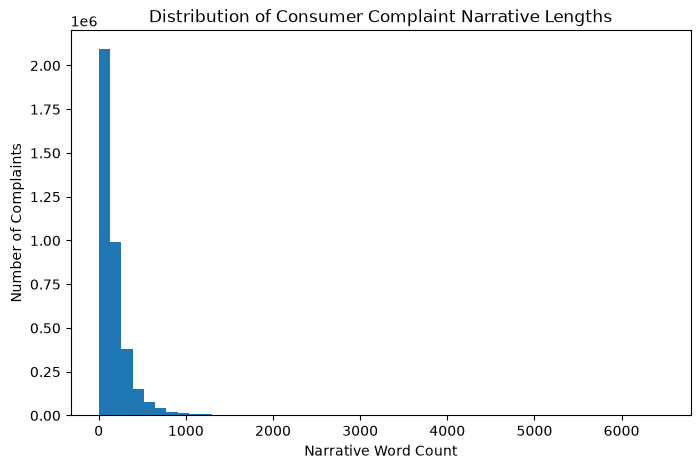

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(word_count_series, bins=50)
plt.xlabel("Narrative Word Count")
plt.ylabel("Number of Complaints")
plt.title("Distribution of Consumer Complaint Narrative Lengths")
plt.show()

In [27]:
short_narratives = (word_count_series < 20).sum()
long_narratives = (word_count_series > 500).sum()

print("Very short narratives under 20 words:", short_narratives)
print("Very long narratives over 500 words:", long_narratives)
print("Shortest narrative word count:", word_count_series.min())
print("Longest narrative word count:", word_count_series.max())

Very short narratives under 20 words: 156347
Very long narratives over 500 words: 203596
Shortest narrative word count: 1
Longest narrative word count: 6469


In [28]:
def map_target_product(product):
    product = str(product).lower()

    if "credit card" in product:
        return "Credit Card"
    elif "personal loan" in product:
        return "Personal Loan"
    elif "savings account" in product:
        return "Savings Account"
    elif "money transfer" in product or "money transfers" in product:
        return "Money Transfer"
    else:
        return None


def clean_text(text):
    text = str(text).lower()

    # Remove common boilerplate phrases
    boilerplate_patterns = [
        r"i am writing to file a complaint",
        r"i am filing this complaint",
        r"this is a complaint",
        r"i would like to file a complaint",
        r"dear sir or madam",
        r"to whom it may concern"
    ]

    for pattern in boilerplate_patterns:
        text = re.sub(pattern, " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove special characters, keep letters, numbers, and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove repeated x placeholders like xxxx
    text = re.sub(r"\b[x]{2,}\b", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [29]:
useful_columns = [
    "Date received",
    "Product",
    "Issue",
    "Company",
    "State",
    "Consumer complaint narrative",
    "Company response to consumer",
    "Timely response?"
]

output_path = PROCESSED_DIR / "complaints_task1_cleaned.csv"

first_chunk = True
total_saved_rows = 0

for chunk in pd.read_csv(
    RAW_PATH,
    usecols=useful_columns,
    chunksize=100_000,
    low_memory=False
):
    # Map product names to the four required categories
    chunk["target_product"] = chunk["Product"].apply(map_target_product)

    # Keep only the four required products
    chunk = chunk[chunk["target_product"].notna()]

    # Remove empty complaint narratives
    chunk = chunk.dropna(subset=["Consumer complaint narrative"])

    chunk["Consumer complaint narrative"] = chunk["Consumer complaint narrative"].astype(str)

    chunk = chunk[
        chunk["Consumer complaint narrative"].str.strip() != ""
    ]

    # Clean narrative text
    chunk["cleaned_narrative"] = chunk["Consumer complaint narrative"].apply(clean_text)

    # Remove narratives that became empty after cleaning
    chunk = chunk[chunk["cleaned_narrative"].str.strip() != ""]

    # Add word count after cleaning
    chunk["cleaned_word_count"] = chunk["cleaned_narrative"].str.split().str.len()

    # Rename columns
    chunk = chunk.rename(columns={
        "Date received": "date_received",
        "Product": "original_product",
        "Issue": "issue",
        "Company": "company",
        "State": "state",
        "Consumer complaint narrative": "original_narrative",
        "Company response to consumer": "company_response",
        "Timely response?": "timely_response"
    })

    total_saved_rows += len(chunk)

    chunk.to_csv(
        output_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Total filtered and cleaned rows saved:", total_saved_rows)
print("Saved file:", output_path)

Total filtered and cleaned rows saved: 563726
Saved file: ../data/processed/complaints_task1_cleaned.csv


In [30]:
clean_df = pd.read_csv(PROCESSED_DIR / "complaints_task1_cleaned.csv")

print("Final cleaned dataset shape:", clean_df.shape)

clean_df.head()

Final cleaned dataset shape: (563726, 11)


,date_received,original_product,issue,original_narrative,company,state,company_response,timely_response,target_product,cleaned_narrative,cleaned_word_count
0,2023-10-24T21:18:35.000Z,Credit card,Getting a credit card,"In good faith, I exercised my right and applie...",AMERICAN EXPRESS COMPANY,TX,Closed with explanation,Yes,Credit Card,in good faith i exercised my right and applied...,604
1,2025-05-27T19:08:14.000Z,Credit card,Fees or interest,On last 40 to 42 months they charge me {$29.00...,BARCLAYS BANK DELAWARE,CA,Closed with explanation,Yes,Credit Card,on last 40 to 42 months they charge me 29 00 p...,43
2,2025-11-17T22:24:08.000Z,Credit card,Getting a credit card,"I received an email today, XX/XX/year>, that m...",SYNCHRONY FINANCIAL,VA,Closed with explanation,Yes,Credit Card,i received an email today year that my paypal ...,175
3,2025-12-15T23:37:01.000Z,"Money transfer, virtual currency, or money ser...",Trouble accessing funds in your mobile or digi...,Never got refund or money to my account.was ch...,M&T BANK CORPORATION,NY,Closed with explanation,Yes,Money Transfer,never got refund or money to my account was ch...,40
4,2026-01-13T15:05:26.000Z,Checking or savings account,Managing an account,Beware of doing business with American Express...,AMERICAN EXPRESS COMPANY,FL,Closed with explanation,No,Savings Account,beware of doing business with american express...,392


In [31]:
clean_df["target_product"].value_counts()

target_product
Credit Card        229716
Savings Account    180729
Money Transfer     119177
Personal Loan       34104
Name: count, dtype: int64

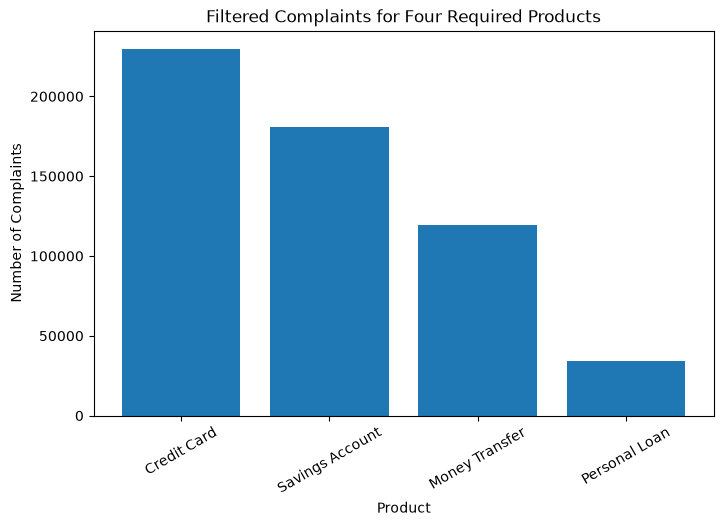

In [32]:
product_counts = clean_df["target_product"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(product_counts.index, product_counts.values)
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.title("Filtered Complaints for Four Required Products")
plt.xticks(rotation=30)
plt.show()

In [33]:
clean_df["cleaned_word_count"].describe()

count    563726.000000
mean        198.115042
std         210.447663
min           1.000000
25%          82.000000
50%         138.000000
75%         249.000000
max        6239.000000
Name: cleaned_word_count, dtype: float64

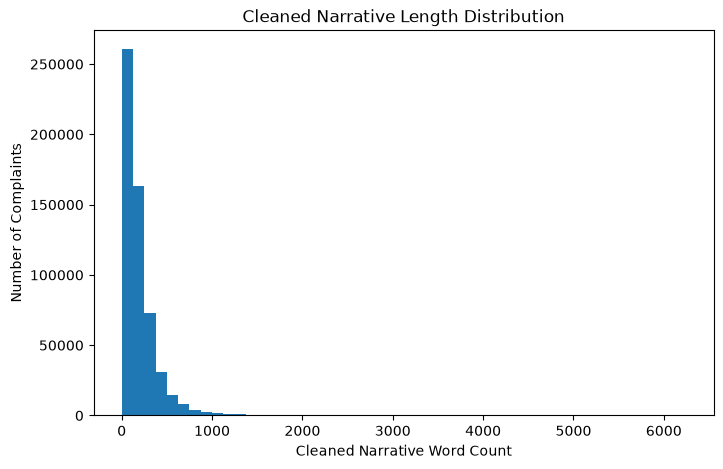

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["cleaned_word_count"], bins=50)
plt.xlabel("Cleaned Narrative Word Count")
plt.ylabel("Number of Complaints")
plt.title("Cleaned Narrative Length Distribution")
plt.show()

In [35]:
clean_df = pd.read_csv("../data/processed/complaints_task1_cleaned.csv")

clean_df[["original_narrative", "cleaned_narrative"]].head()

,original_narrative,cleaned_narrative
0,"In good faith, I exercised my right and applie...",in good faith i exercised my right and applied...
1,On last 40 to 42 months they charge me {$29.00...,on last 40 to 42 months they charge me 29 00 p...
2,"I received an email today, XX/XX/year>, that m...",i received an email today year that my paypal ...
3,Never got refund or money to my account.was ch...,never got refund or money to my account was ch...
4,Beware of doing business with American Express...,beware of doing business with american express...


In [36]:
print("Any uppercase letters left?")
print(clean_df["cleaned_narrative"].str.contains(r"[A-Z]", regex=True).sum())

print("Empty cleaned narratives:")
print((clean_df["cleaned_narrative"].str.strip() == "").sum())

Any uppercase letters left?
0
Empty cleaned narratives:
0


In [37]:
clean_df = pd.read_csv("../data/processed/complaints_task1_cleaned.csv")

print("Number of product categories:", clean_df["target_product"].nunique())
print(clean_df["target_product"].value_counts())

Number of product categories: 4
target_product
Credit Card        229716
Savings Account    180729
Money Transfer     119177
Personal Loan       34104
Name: count, dtype: int64


In [38]:
import sys
print(sys.version)

3.14.5 (main, May 10 2026, 10:21:34) [Clang 21.0.0 (clang-2100.0.123.102)]


In [1]:
import sys

print("Executable:", sys.executable)
print("Version:", sys.version)

Executable: /Users/mac/rag-complaint-chatbot/.venv/bin/python
Version: 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]
